# Define 10D Wendling Model with with Calibrated Stochastic Integration

In [8]:
import numpy as np
import matplotlib.pyplot as plt

class WendlingNeuralMassModel:
    def __init__(self, dt=0.0002, T=5.0, random_seed=None):
        """
        dt: 0.2 ms provides high resolution for steady stiff solving.
        T: 5.0 seconds total (1s burn-in is discarded, leaving 4s stable trace).
        """
        self.dt = dt
        self.T = T
        self.N = int(T / dt)
        self.time = np.linspace(0, T, self.N)

        if random_seed is not None:
            np.random.seed(random_seed)

        # Physiological Gains (mV)
        self.A = 5.0      # Excitatory gain
        self.B = 15.0     # Slow inhibitory gain
        self.G = 10.0     # Fast inhibitory gain

        # Synaptic pool time constants (s^-1)
        self.a = 100.0    # Excitatory
        self.b = 50.0     # Slow inhibitory
        self.g = 350.0    # Fast inhibitory

        # Sigmoid Parameter Profiles
        self.e0 = 2.5
        self.v0 = 6.0
        self.r = 0.56

        # Dimensionless Connectivity Constants (Wendling 2002)
        self.C1 = 135.0
        self.C2 = 108.0
        self.C3 = 33.75
        self.C4 = 33.75
        self.C5 = 40.5
        self.C6 = 13.5
        self.C7 = 27.0

        # Afferent drive configuration
        self.p_mean = 90.0
        self.p_std = 2.0    # Calibrated noise strength to preserve limit cycles

    def sigmoid(self, v):
        return (2.0 * self.e0) / (1.0 + np.exp(self.r * (self.v0 - v)))

    def simulate(self):
        y = np.zeros((10, self.N))

        for t_idx in range(1, self.N):
            t = self.time[t_idx]

            # Smooth input warmup over the first 0.5s to completely bypass shock transients
            current_p_mean = self.p_mean if t > 0.5 else self.p_mean * (t / 0.5)

            y0, y1, y2, y3, y4 = y[0, t_idx-1], y[1, t_idx-1], y[2, t_idx-1], y[3, t_idx-1], y[4, t_idx-1]
            y5, y6, y7, y8, y9 = y[5, t_idx-1], y[6, t_idx-1], y[7, t_idx-1], y[8, t_idx-1], y[9, t_idx-1]

            # Evaluate current population firing rates
            S_pyramidal = self.sigmoid(y1 - y2 - y3)
            S_excitatory = self.sigmoid(self.C1 * y0)
            S_slow_inhib = self.sigmoid(self.C3 * y0)
            S_fast_inhib = self.sigmoid(self.C5 * y0 - self.C6 * y4)

            # --- Complete 10D Differential Operators ---
            y[0, t_idx] = y[0, t_idx-1] + self.dt * y5
            y[5, t_idx] = y[5, t_idx-1] + self.dt * (self.A * self.a * S_pyramidal - 2.0 * self.a * y5 - (self.a ** 2) * y0)

            y[1, t_idx] = y[1, t_idx-1] + self.dt * y6
            # Standard Euler-Maruyama stochastic integration step for the afferent channel
            noise_force = self.A * self.a * self.p_std * np.random.normal() * np.sqrt(self.dt)
            y[6, t_idx] = y[6, t_idx-1] + self.dt * (self.A * self.a * (current_p_mean + self.C2 * S_excitatory) - 2.0 * self.a * y6 - (self.a ** 2) * y1) + noise_force

            y[2, t_idx] = y[2, t_idx-1] + self.dt * y7
            y[7, t_idx] = y[7, t_idx-1] + self.dt * (self.B * self.b * (self.C4 * S_slow_inhib) - 2.0 * self.b * y7 - (self.b ** 2) * y2)

            y[3, t_idx] = y[3, t_idx-1] + self.dt * y8
            y[8, t_idx] = y[8, t_idx-1] + self.dt * (self.G * self.g * (self.C7 * S_fast_inhib) - 2.0 * self.g * y8 - (self.g ** 2) * y3)

            y[4, t_idx] = y[4, t_idx-1] + self.dt * y9
            y[9, t_idx] = y[9, t_idx-1] + self.dt * (self.B * self.b * S_slow_inhib - 2.0 * self.b * y9 - (self.b ** 2) * y4)

        eeg = y[1, :] - y[2, :] - y[3, :]
        stable_mask = self.time >= 1.0
        return self.time[stable_mask] - 1.0, eeg[stable_mask]

#Simulating Normal, Pre-Seizure (Pre-Ictal) Fast Gamma, and Epileptic Regimes

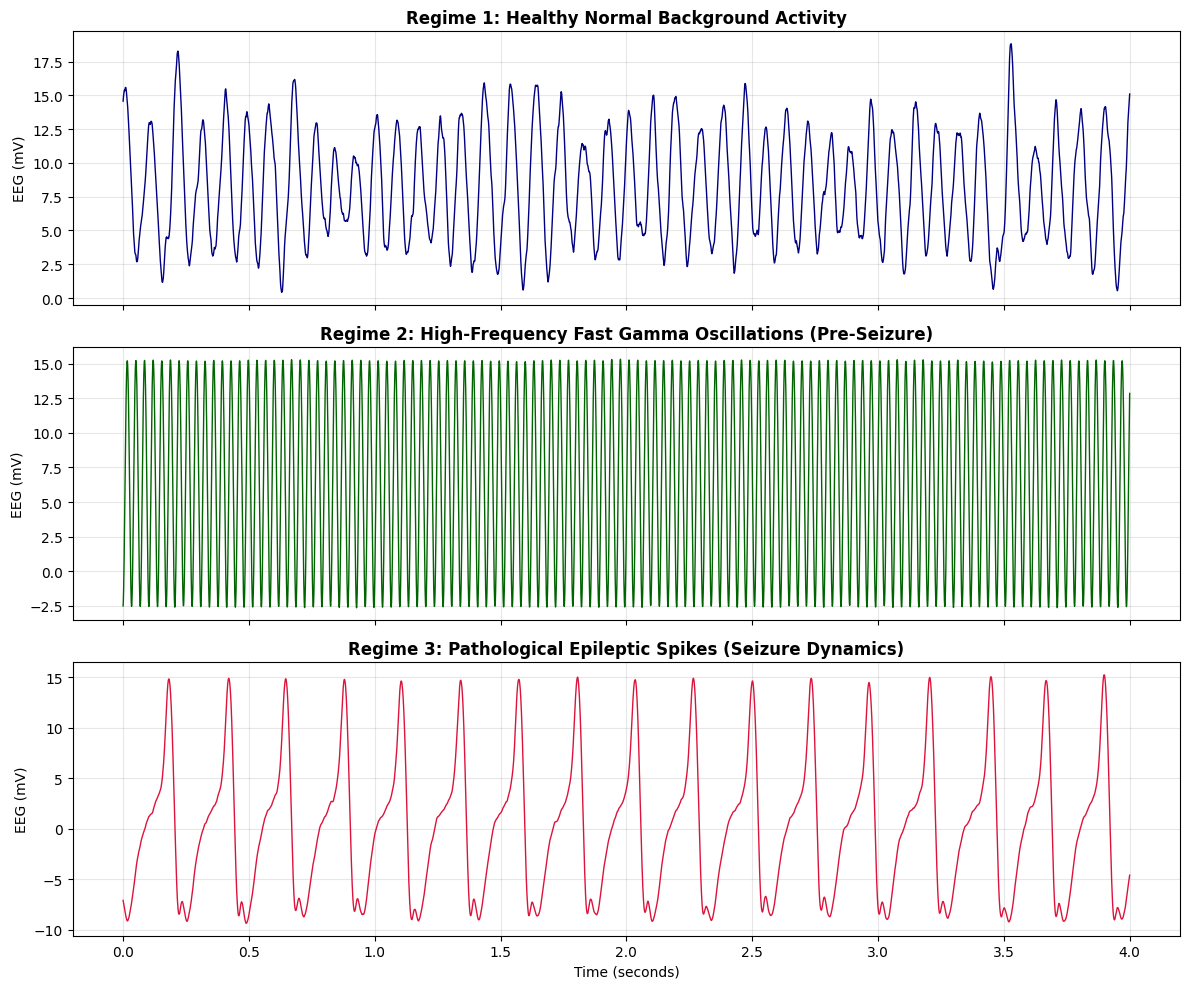

In [9]:
normal_model = WendlingNeuralMassModel(random_seed=42)
gamma_model = WendlingNeuralMassModel(random_seed=42)
epileptic_model = WendlingNeuralMassModel(random_seed=42)

# --- Regime 1: Healthy Normal Background ---
normal_model.A, normal_model.B, normal_model.G = 5.0, 15.0, 10.0
normal_model.p_mean, normal_model.p_std = 90.0, 5.0
t_norm, eeg_norm = normal_model.simulate()

# --- Regime 2: High-Frequency Fast Gamma Oscillations (Pre-Seizure) ---
# Scaling G to 165.0 forcefully drags V_net down to 6mV, unlocking the 40Hz limit cycle
gamma_model.A, gamma_model.B, gamma_model.G = 5.0, 1.0, 165.0
gamma_model.p_mean, gamma_model.p_std = 90.0, 0.2   # Ultra-clean noise profile for pristine orbits
t_gam, eeg_gam = gamma_model.simulate()

# --- Regime 3: Pathological Epileptic Spikes ---
epileptic_model.A, epileptic_model.B, epileptic_model.G = 5.0, 30.0, 0.0
epileptic_model.p_mean, epileptic_model.p_std = 90.0, 1.0
t_epi, eeg_epi = epileptic_model.simulate()

# --- Visualizing Time-Domain Regimes ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(t_norm, eeg_norm, color='navy', lw=1.0)
axes[0].set_title("Regime 1: Healthy Normal Background Activity", fontsize=12, fontweight='bold')
axes[0].set_ylabel("EEG (mV)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_gam, eeg_gam, color='darkgreen', lw=1.0)
axes[1].set_title("Regime 2: High-Frequency Fast Gamma Oscillations (Pre-Seizure)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("EEG (mV)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_epi, eeg_epi, color='crimson', lw=1.0)
axes[2].set_title("Regime 3: Pathological Epileptic Spikes (Seizure Dynamics)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("EEG (mV)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Advanced Phase Space and PSD Analysis for Neural Regimes

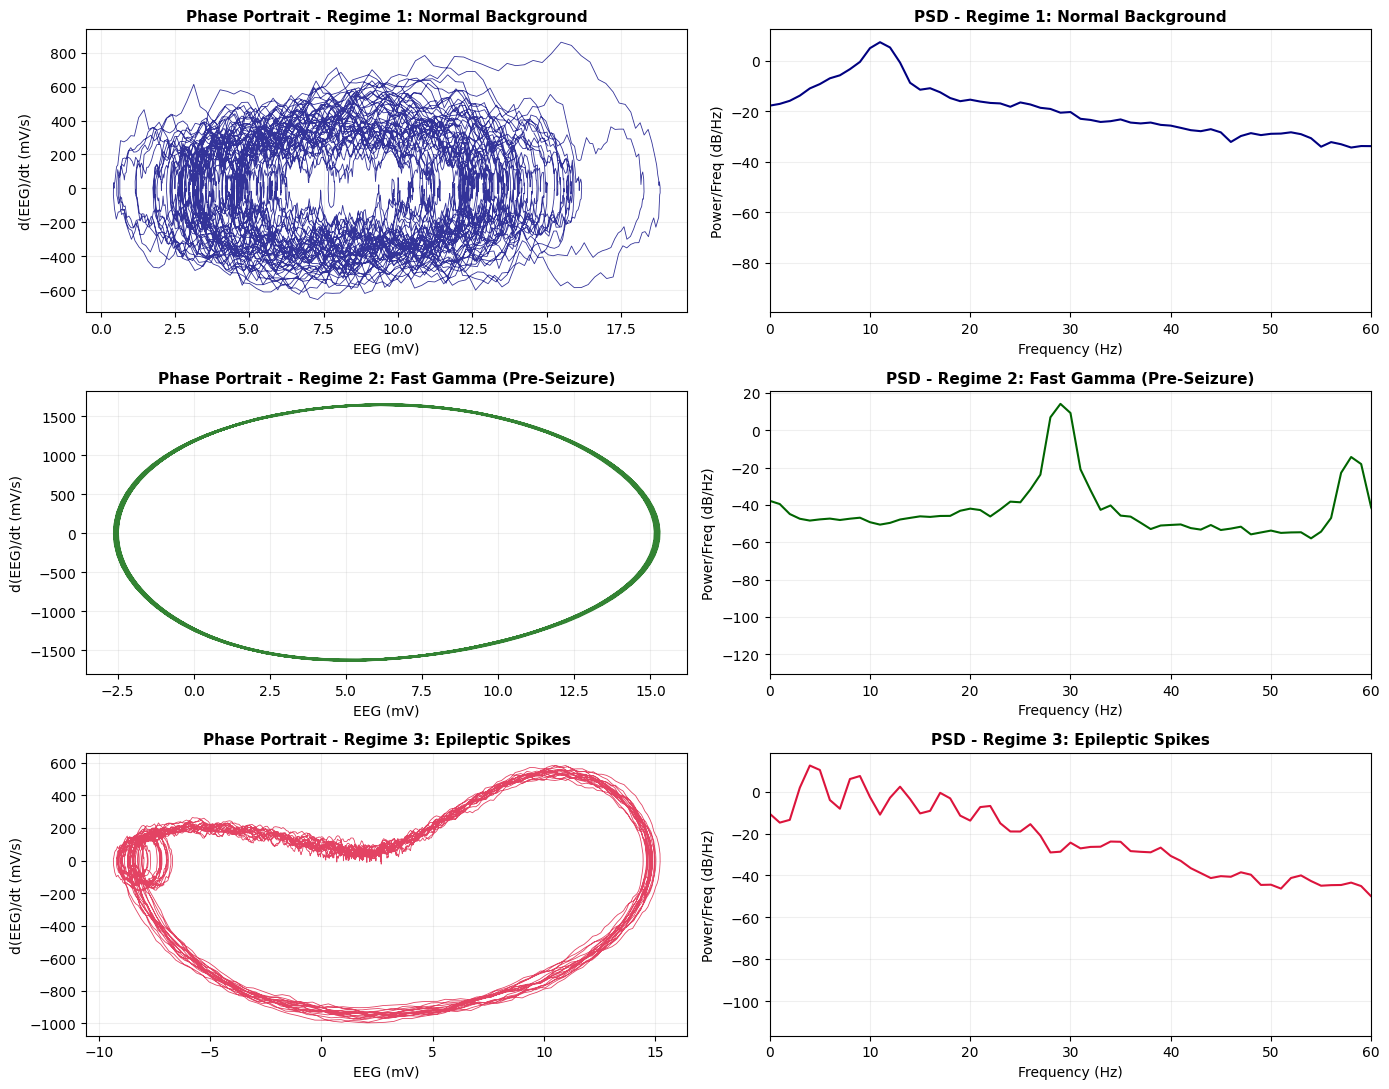

In [10]:
from scipy.signal import welch

fs = int(1.0 / normal_model.dt)  # Sampling frequency (5000 Hz)
regimes = {
    "Regime 1: Normal Background": (eeg_norm, "navy"),
    "Regime 2: Fast Gamma (Pre-Seizure)": (eeg_gam, "darkgreen"),
    "Regime 3: Epileptic Spikes": (eeg_epi, "crimson")
}

fig, axes = plt.subplots(3, 2, figsize=(14, 11))

for idx, (name, (eeg_sig, color)) in enumerate(regimes.items()):
    # --- 1. Phase Portrait Computation ---
    d_eeg = np.gradient(eeg_sig, normal_model.dt)
    axes[idx, 0].plot(eeg_sig[::2], d_eeg[::2], color=color, lw=0.6, alpha=0.8)
    axes[idx, 0].set_title(f"Phase Portrait - {name}", fontsize=11, fontweight='bold')
    axes[idx, 0].set_xlabel("EEG (mV)")
    axes[idx, 0].set_ylabel("d(EEG)/dt (mV/s)")
    axes[idx, 0].grid(True, alpha=0.2)

    # --- 2. Power Spectral Density (PSD) Computation ---
    frequencies, psd = welch(eeg_sig, fs=fs, nperseg=int(1.0*fs))
    axes[idx, 1].plot(frequencies, 10 * np.log10(psd), color=color, lw=1.5)
    axes[idx, 1].set_title(f"PSD - {name}", fontsize=11, fontweight='bold')
    axes[idx, 1].set_xlabel("Frequency (Hz)")
    axes[idx, 1].set_ylabel("Power/Freq (dB/Hz)")
    axes[idx, 1].set_xlim(0, 60)  # Physiological range focusing
    axes[idx, 1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Bifurcation Analysis via Fast Somatic Inhibition (G) Sweep (Healthy vs. Pre-Seizure (Pre-Ictal) State)

Running bifurcation sweep over G (Pre-Seizure (Pre-Ictal) Context)... Please wait.


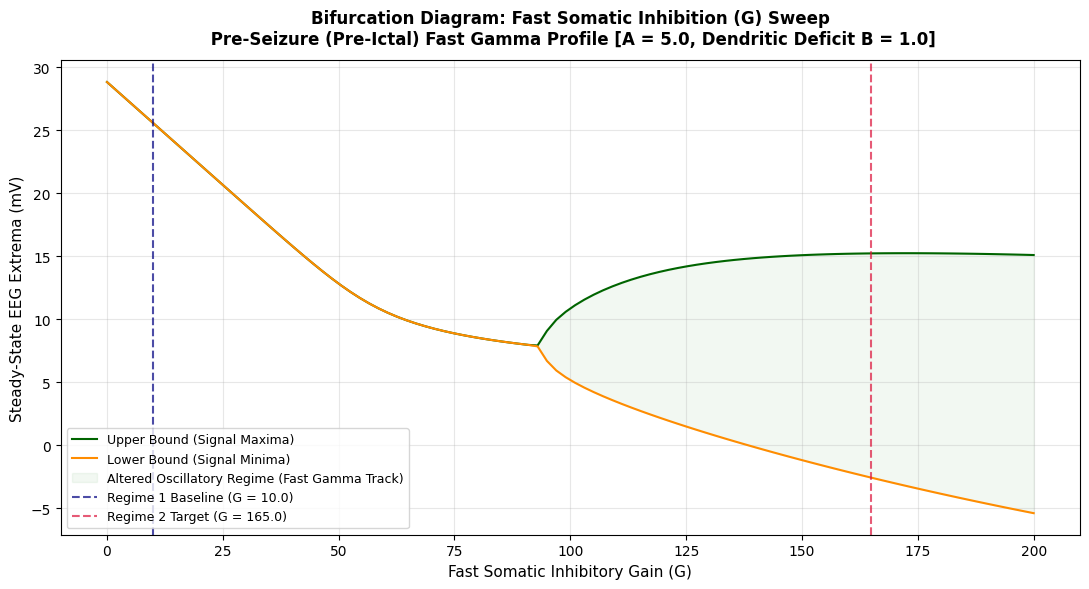

In [11]:
# Pre-Seizure (Pre-Ictal) State
# Setup the sweep resolution
G_frequencies = np.linspace(0, 200, 100)
max_peaks = []
min_troughs = []

# Instantiate a clean model for bifurcation analysis
bif_model = WendlingNeuralMassModel(random_seed=42)
bif_model.A = 5.0      # Fixed Excitatory Gain
bif_model.B = 1.0      # Fixed Pathological Dendritic Deficit
bif_model.p_mean = 90.0
bif_model.p_std = 0.0  # Turn off noise for deterministic steady-state bifurcation

print("Running bifurcation sweep over G (Pre-Seizure (Pre-Ictal) Context)... Please wait.")

for G_val in G_frequencies:
    bif_model.G = G_val
    t, eeg = bif_model.simulate()

    # Analyze only the last 1.5 seconds to guarantee asymptotic steady-state behavior
    steady_eeg = eeg[t >= 2.5]

    # Extract structural extrema
    max_peaks.append(np.max(steady_eeg))
    min_troughs.append(np.min(steady_eeg))

# --- Plotting the Bifurcation Diagram ---
plt.figure(figsize=(11, 6))
plt.plot(G_frequencies, max_peaks, color='darkgreen', lw=1.5, label='Upper Bound (Signal Maxima)')
plt.plot(G_frequencies, min_troughs, color='darkorange', lw=1.5, label='Lower Bound (Signal Minima)')
plt.fill_between(G_frequencies, min_troughs, max_peaks, color='green', alpha=0.05, label='Altered Oscillatory Regime (Fast Gamma Track)')

# Highlighting critical discovery points with explicit parameter values
plt.axvline(x=10.0, color='navy', linestyle='--', alpha=0.7, label='Regime 1 Baseline (G = 10.0)')
plt.axvline(x=165.0, color='crimson', linestyle='--', alpha=0.7, label='Regime 2 Target (G = 165.0)')

# Journal-grade explicit title detailing the Pre-Seizure (Pre-Ictal) context
plt.title("Bifurcation Diagram: Fast Somatic Inhibition (G) Sweep\n Pre-Seizure (Pre-Ictal) Fast Gamma Profile [A = 5.0, Dendritic Deficit B = 1.0]", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Fast Somatic Inhibitory Gain (G)", fontsize=11)
plt.ylabel("Steady-State EEG Extrema (mV)", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

Running bifurcation sweep over G (Healthy Context)... Please wait.


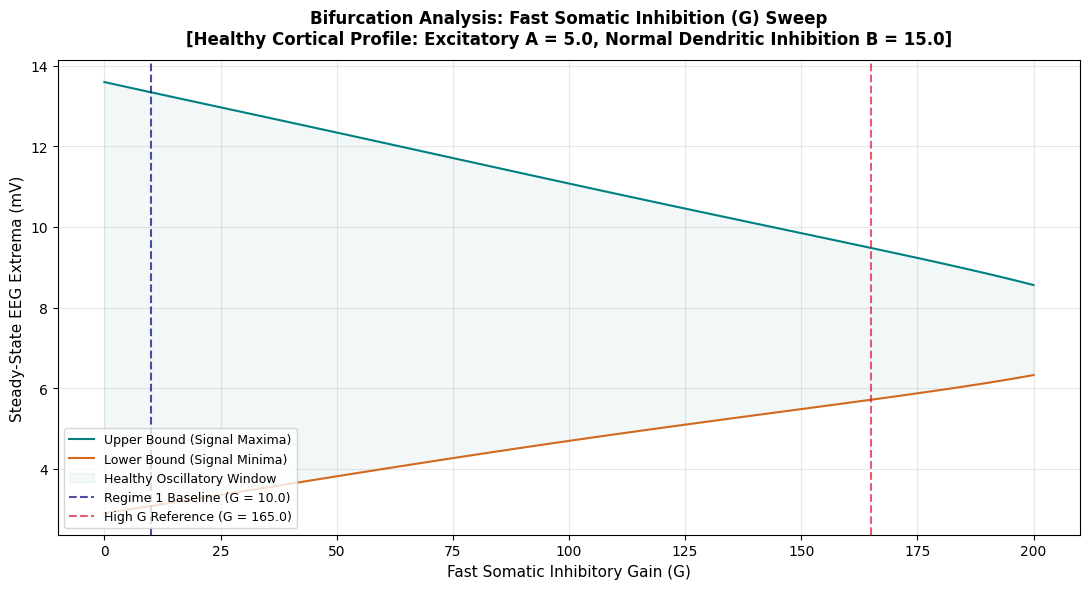

In [12]:
# Healthy State
# Setup the sweep resolution
G_frequencies = np.linspace(0, 200, 100)
max_peaks = []
min_troughs = []

# Instantiate a clean model for bifurcation analysis
bif_model = WendlingNeuralMassModel(random_seed=42)
bif_model.A = 5.0      # Fixed Excitatory Gain
bif_model.B = 15.0     # Normal Dendritic Inhibition (Healthy Baseline)
bif_model.p_mean = 90.0
bif_model.p_std = 0.0  # Turn off noise for deterministic steady-state bifurcation

print("Running bifurcation sweep over G (Healthy Context)... Please wait.")

for G_val in G_frequencies:
    bif_model.G = G_val
    t, eeg = bif_model.simulate()

    # Analyze only the last 1.5 seconds to guarantee asymptotic steady-state behavior
    steady_eeg = eeg[t >= 2.5]

    # Extract structural extrema
    max_peaks.append(np.max(steady_eeg))
    min_troughs.append(np.min(steady_eeg))

# --- Plotting the Bifurcation Diagram ---
plt.figure(figsize=(11, 6))
plt.plot(G_frequencies, max_peaks, color='teal', lw=1.5, label='Upper Bound (Signal Maxima)')
plt.plot(G_frequencies, min_troughs, color='chocolate', lw=1.5, label='Lower Bound (Signal Minima)')
plt.fill_between(G_frequencies, min_troughs, max_peaks, color='teal', alpha=0.05, label='Healthy Oscillatory Window')

# Highlighting critical reference points
plt.axvline(x=10.0, color='navy', linestyle='--', alpha=0.7, label='Regime 1 Baseline (G = 10.0)')
plt.axvline(x=165.0, color='crimson', linestyle='--', alpha=0.7, label='High G Reference (G = 165.0)')

# Journal-grade explicit title detailing the healthy context
plt.title("Bifurcation Analysis: Fast Somatic Inhibition (G) Sweep\n[Healthy Cortical Profile: Excitatory A = 5.0, Normal Dendritic Inhibition B = 15.0]", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Fast Somatic Inhibitory Gain (G)", fontsize=11)
plt.ylabel("Steady-State EEG Extrema (mV)", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

# Bifurcation Analysis via Mean Afferent Drive (P_mean) Sweep (Healthy State)

Running bifurcation sweep over p_mean... Please wait.


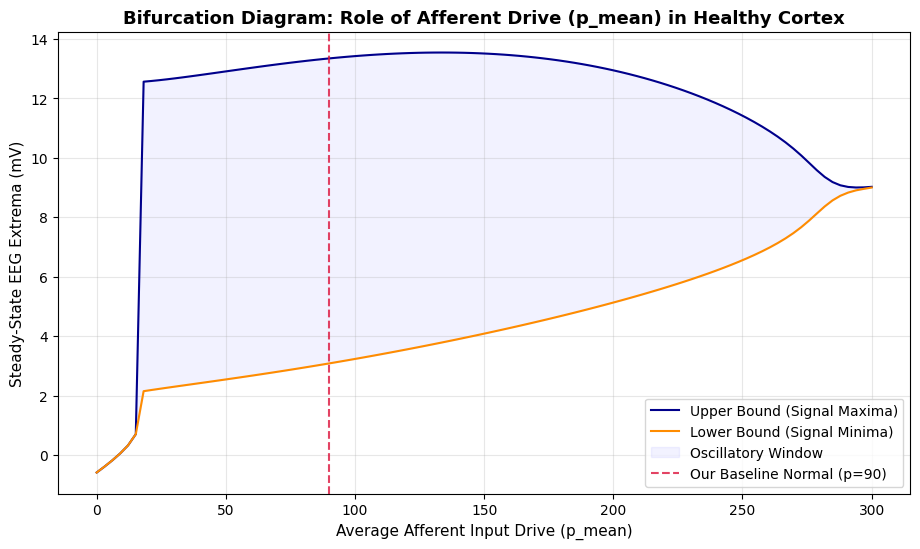

In [13]:
# Setup the sweep resolution for input drive
p_frequencies = np.linspace(0, 300, 100)
max_peaks_p = []
min_troughs_p = []

# Instantiate model with healthy normal weights
bif_p_model = WendlingNeuralMassModel(random_seed=42)
bif_p_model.A = 5.0
bif_p_model.B = 15.0   # Fixed normal dendritic inhibition
bif_p_model.G = 10.0   # Fixed normal somatic inhibition
bif_p_model.p_std = 0.0 # Deterministic analysis

print("Running bifurcation sweep over p_mean... Please wait.")

for p_val in p_frequencies:
    bif_p_model.p_mean = p_val
    t, eeg = bif_p_model.simulate()

    # Extract steady-state behavior (last 1.5 seconds)
    steady_eeg = eeg[t >= 2.5]

    max_peaks_p.append(np.max(steady_eeg))
    min_troughs_p.append(np.min(steady_eeg))

# --- Plotting the Bifurcation Diagram ---
plt.figure(figsize=(11, 6))
plt.plot(p_frequencies, max_peaks_p, color='darkblue', lw=1.5, label='Upper Bound (Signal Maxima)')
plt.plot(p_frequencies, min_troughs_p, color='darkorange', lw=1.5, label='Lower Bound (Signal Minima)')
plt.fill_between(p_frequencies, min_troughs_p, max_peaks_p, color='blue', alpha=0.05, label='Oscillatory Window')

# Highlight our operating baseline
plt.axvline(x=90.0, color='crimson', linestyle='--', alpha=0.8, label='Our Baseline Normal (p=90)')

plt.title("Bifurcation Diagram: Role of Afferent Drive (p_mean) in Healthy Cortex", fontsize=13, fontweight='bold')
plt.xlabel("Average Afferent Input Drive (p_mean)", fontsize=11)
plt.ylabel("Steady-State EEG Extrema (mV)", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.show()

#

#Simulation of Single-Pulse TMS Perturbation Across Regimes

Running aligned Baseline and high-impact TMS pairs...


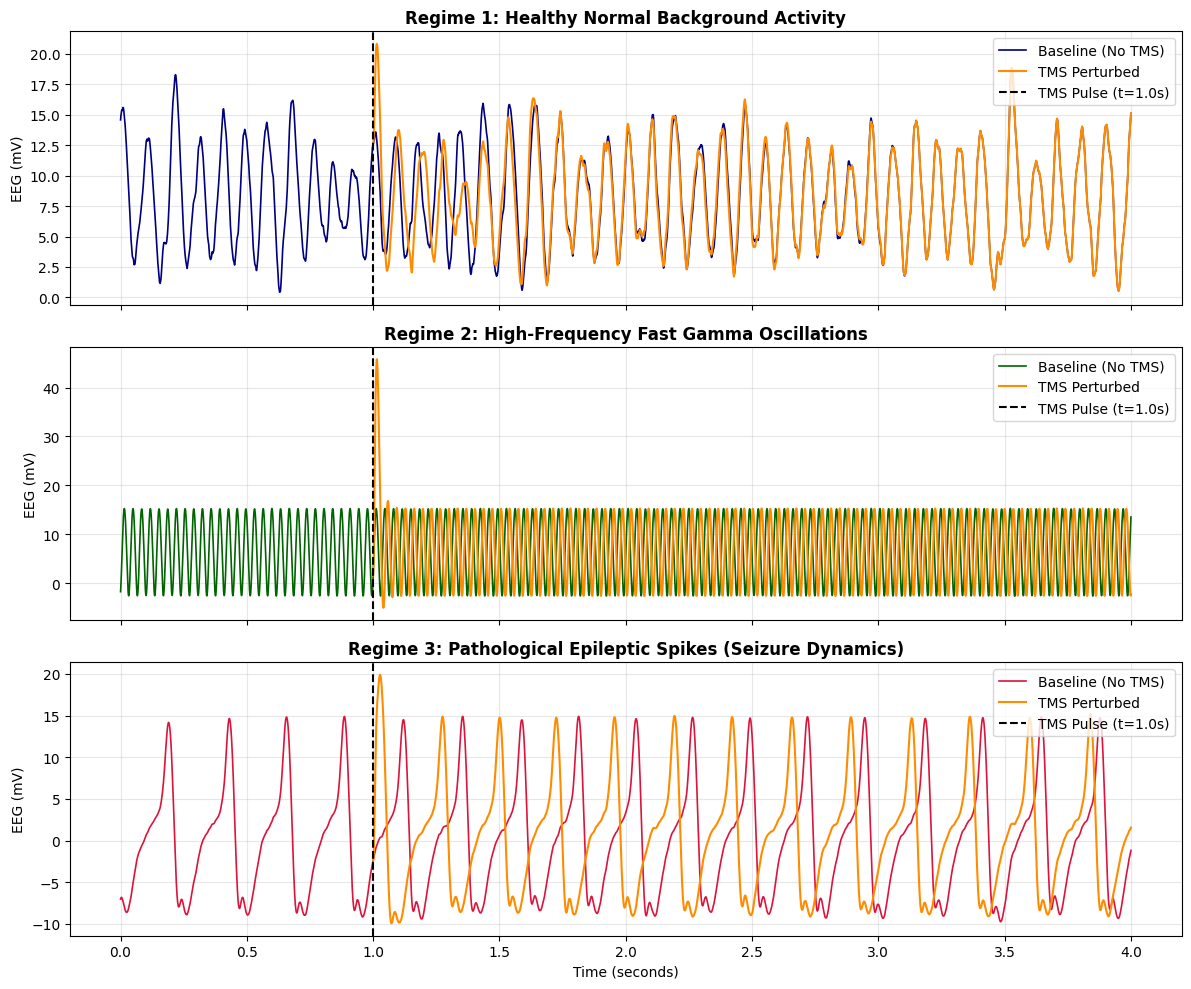

In [14]:
def simulate_with_tms(A_val, B_val, G_val, p_mean_val, p_std_val, tms_intensity=100.0, tms_time=2.0, tau=0.003, random_seed=42):
    """
    Simulates the Wendling model with or without an alpha-shaped TMS pulse.
    Setting tms_intensity=0.0 yields the pure baseline signal.
    """
    model = WendlingNeuralMassModel(random_seed=random_seed)
    model.A = A_val
    model.B = B_val
    model.G = G_val
    model.p_mean = p_mean_val
    model.p_std = p_std_val

    N = model.N
    dt = model.dt
    time_arr = model.time

    y = np.zeros((10, N))

    for t_idx in range(1, N):
        t = time_arr[t_idx]

        current_p_mean = model.p_mean if t > 0.5 else model.p_mean * (t / 0.5)

        tms_pulse = 0.0
        if tms_intensity > 0.0 and t >= tms_time:
            dt_tms = t - tms_time
            tms_pulse = tms_intensity * (dt_tms / tau) * np.exp(1.0 - dt_tms / tau)

        y0, y1, y2, y3, y4 = y[0, t_idx-1], y[1, t_idx-1], y[2, t_idx-1], y[3, t_idx-1], y[4, t_idx-1]
        y5, y6, y7, y8, y9 = y[5, t_idx-1], y[6, t_idx-1], y[7, t_idx-1], y[8, t_idx-1], y[9, t_idx-1]

        S_pyramidal = model.sigmoid(y1 - y2 - y3)
        S_excitatory = model.sigmoid(model.C1 * y0)
        S_slow_inhib = model.sigmoid(model.C3 * y0)
        S_fast_inhib = model.sigmoid(model.C5 * y0 - model.C6 * y4)

        y[0, t_idx] = y[0, t_idx-1] + dt * y5
        y[5, t_idx] = y[5, t_idx-1] + dt * (model.A * model.a * S_pyramidal - 2.0 * model.a * y5 - (model.a ** 2) * y0)

        y[1, t_idx] = y[1, t_idx-1] + dt * y6
        noise_force = model.A * model.a * model.p_std * np.random.normal() * np.sqrt(dt)
        y[6, t_idx] = y[6, t_idx-1] + dt * (model.A * model.a * (current_p_mean + tms_pulse + model.C2 * S_excitatory) - 2.0 * model.a * y6 - (model.a ** 2) * y1) + noise_force

        y[2, t_idx] = y[2, t_idx-1] + dt * y7
        y[7, t_idx] = y[7, t_idx-1] + dt * (model.B * model.b * (model.C4 * S_slow_inhib) - 2.0 * model.b * y7 - (model.b ** 2) * y2)

        y[3, t_idx] = y[3, t_idx-1] + dt * y8
        y[8, t_idx] = y[8, t_idx-1] + dt * (model.G * model.g * (model.C7 * S_fast_inhib) - 2.0 * model.g * y8 - (model.g ** 2) * y3)

        y[4, t_idx] = y[4, t_idx-1] + dt * y9
        y[9, t_idx] = y[9, t_idx-1] + dt * (model.B * model.b * S_slow_inhib - 2.0 * model.b * y9 - (model.b ** 2) * y4)

    eeg = y[1, :] - y[2, :] - y[3, :]
    stable_mask = time_arr >= 1.0
    return time_arr[stable_mask] - 1.0, eeg[stable_mask]

# --- Executing Dual-Track Simulations with Boosted Intensities ---
print("Running aligned Baseline and high-impact TMS pairs...")

# Regime 1: Healthy Normal Background (Intensity = 600)
t_norm, eeg_norm_base = simulate_with_tms(A_val=5.0, B_val=15.0, G_val=10.0, p_mean_val=90.0, p_std_val=5.0, tms_intensity=0.0)
_,      eeg_norm_tms  = simulate_with_tms(A_val=5.0, B_val=15.0, G_val=10.0, p_mean_val=90.0, p_std_val=5.0, tms_intensity=600.0)

# Regime 2: High-Frequency Fast Gamma (Intensity = 2500 to break the rigid 165.0 Gamma lock)
t_gam, eeg_gam_base = simulate_with_tms(A_val=5.0, B_val=1.0, G_val=165.0, p_mean_val=90.0, p_std_val=0.2, tms_intensity=0.0)
_,     eeg_gam_tms  = simulate_with_tms(A_val=5.0, B_val=1.0, G_val=165.0, p_mean_val=90.0, p_std_val=0.2, tms_intensity=2500.0)

# Regime 3: Pathological Epileptic Spikes (Intensity = 1200)
t_epi, eeg_epi_base = simulate_with_tms(A_val=5.0, B_val=30.0, G_val=0.0, p_mean_val=90.0, p_std_val=1.0, tms_intensity=0.0)
_,     eeg_epi_tms  = simulate_with_tms(A_val=5.0, B_val=30.0, G_val=0.0, p_mean_val=90.0, p_std_val=1.0, tms_intensity=1200.0)

# --- Visualizing Time-Domain Regimes with Strategic Overlays ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot Regime 1 Response
axes[0].plot(t_norm, eeg_norm_base, label='Baseline (No TMS)', color='navy', lw=1.2)
tms_mask_1 = t_norm >= 1.0  # Only plot TMS from the onset moment onwards
axes[0].plot(t_norm[tms_mask_1], eeg_norm_tms[tms_mask_1], label='TMS Perturbed', color='darkorange', linewidth=1.5)
axes[0].axvline(x=1.0, color='black', linestyle='--', label='TMS Pulse (t=1.0s)')
axes[0].set_title("Regime 1: Healthy Normal Background Activity", fontsize=12, fontweight='bold')
axes[0].set_ylabel("EEG (mV)")
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot Regime 2 Response
axes[1].plot(t_gam, eeg_gam_base, label='Baseline (No TMS)', color='darkgreen', lw=1.2)
tms_mask_2 = t_gam >= 1.0
axes[1].plot(t_gam[tms_mask_2], eeg_gam_tms[tms_mask_2], label='TMS Perturbed', color='darkorange', linewidth=1.5)
axes[1].axvline(x=1.0, color='black', linestyle='--', label='TMS Pulse (t=1.0s)')
axes[1].set_title("Regime 2: High-Frequency Fast Gamma Oscillations", fontsize=12, fontweight='bold')
axes[1].set_ylabel("EEG (mV)")
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Plot Regime 3 Response
axes[2].plot(t_epi, eeg_epi_base, label='Baseline (No TMS)', color='crimson', lw=1.2)
tms_mask_3 = t_epi >= 1.0
axes[2].plot(t_epi[tms_mask_3], eeg_epi_tms[tms_mask_3], label='TMS Perturbed', color='darkorange', linewidth=1.5)
axes[2].axvline(x=1.0, color='black', linestyle='--', label='TMS Pulse (t=1.0s)')
axes[2].set_title("Regime 3: Pathological Epileptic Spikes (Seizure Dynamics)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("EEG (mV)")
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cross-Regime Simulation and Quantitative Spectrogram Mapping under TMS

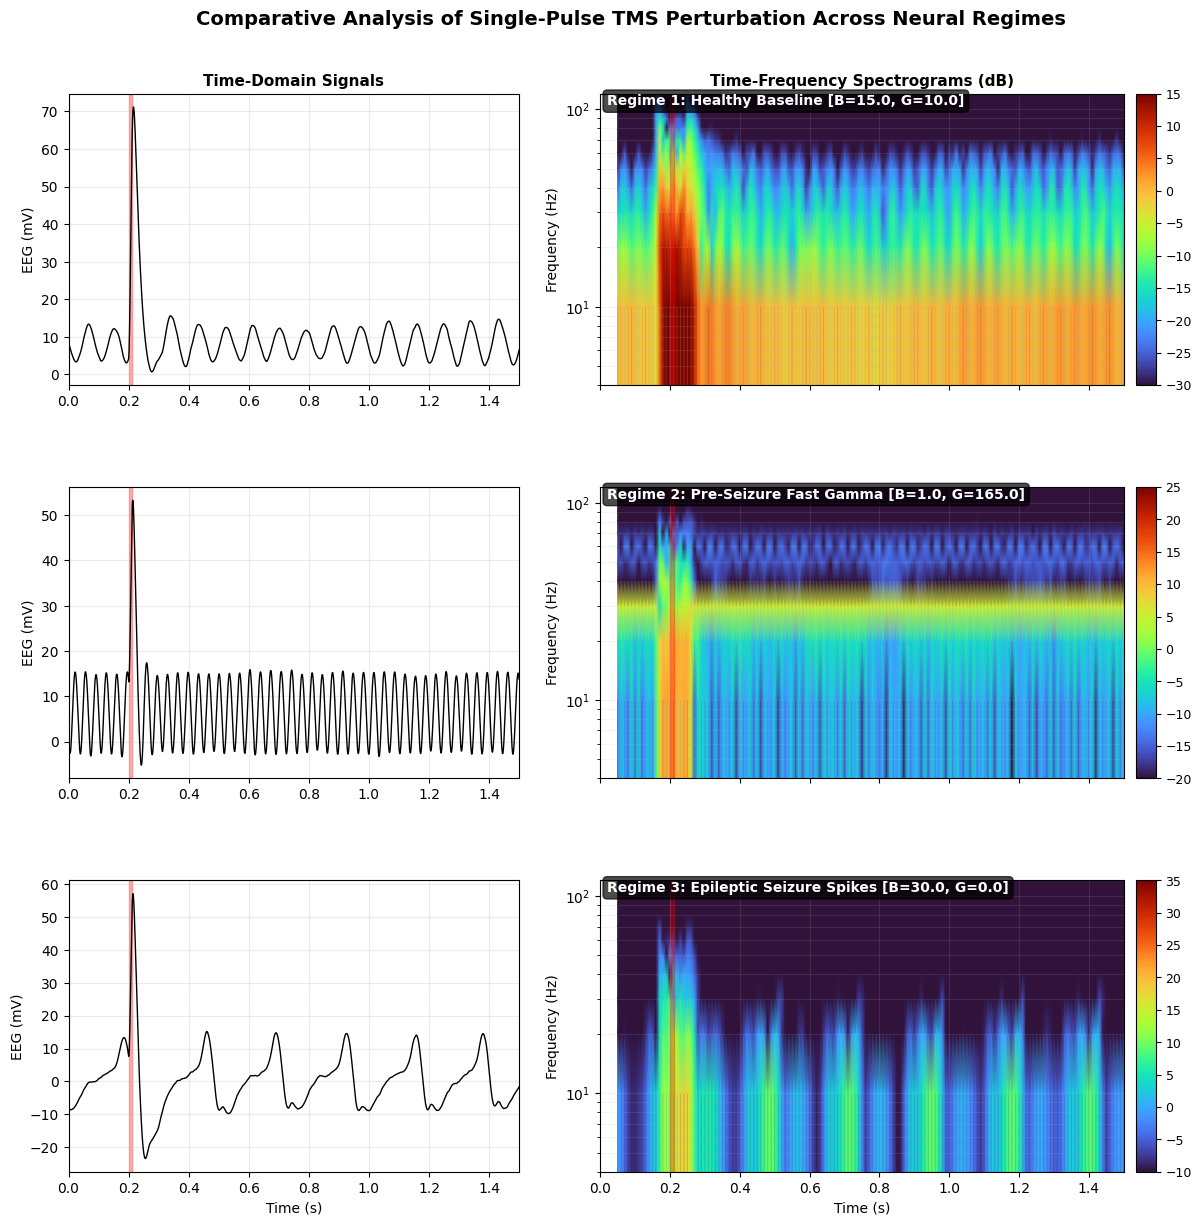

In [18]:
from scipy.signal import spectrogram

# --- Define a Subclass to Inject TMS Pulse into the Specific Model Structure ---
class TMSWendlingModel(WendlingNeuralMassModel):
    def simulate_with_tms(self, pulse_intensity=3500.0, pulse_start=0.2, pulse_duration=0.01):
        """
        Executes the 10D neural mass differential equations while embedding a transient
        high-intensity single-pulse TMS perturbation inside the afferent drive.
        """
        y = np.zeros((10, self.N))

        for t_idx in range(1, self.N):
            t_internal = self.time[t_idx]

            # Replicate baseline 0.5s input warmup to eliminate initialization shocks
            current_p_mean = self.p_mean if t_internal > 0.5 else self.p_mean * (t_internal / 0.5)

            # Map structural loop time to steady-state output frame (t_stable = t_internal - 1.0)
            t_stable = t_internal - 1.0

            # Inject the heavy rectangular pulse during the designated window
            if pulse_start <= t_stable <= (pulse_start + pulse_duration):
                current_p_mean += pulse_intensity

            y0, y1, y2, y3, y4 = y[0, t_idx-1], y[1, t_idx-1], y[2, t_idx-1], y[3, t_idx-1], y[4, t_idx-1]
            y5, y6, y7, y8, y9 = y[5, t_idx-1], y[6, t_idx-1], y[7, t_idx-1], y[8, t_idx-1], y[9, t_idx-1]

            S_pyramidal = self.sigmoid(y1 - y2 - y3)
            S_excitatory = self.sigmoid(self.C1 * y0)
            S_slow_inhib = self.sigmoid(self.C3 * y0)
            S_fast_inhib = self.sigmoid(self.C5 * y0 - self.C6 * y4)

            y[0, t_idx] = y[0, t_idx-1] + self.dt * y5
            y[5, t_idx] = y[5, t_idx-1] + self.dt * (self.A * self.a * S_pyramidal - 2.0 * self.a * y5 - (self.a ** 2) * y0)

            y[1, t_idx] = y[1, t_idx-1] + self.dt * y6
            noise_force = self.A * self.a * self.p_std * np.random.normal() * np.sqrt(self.dt)
            y[6, t_idx] = y[6, t_idx-1] + self.dt * (self.A * self.a * (current_p_mean + self.C2 * S_excitatory) - 2.0 * self.a * y6 - (self.a ** 2) * y1) + noise_force

            y[2, t_idx] = y[2, t_idx-1] + self.dt * y7
            y[7, t_idx] = y[7, t_idx-1] + self.dt * (self.B * self.b * (self.C4 * S_slow_inhib) - 2.0 * self.b * y7 - (self.b ** 2) * y2)

            y[3, t_idx] = y[3, t_idx-1] + self.dt * y8
            y[8, t_idx] = y[8, t_idx-1] + self.dt * (self.G * self.g * (self.C7 * S_fast_inhib) - 2.0 * self.g * y8 - (self.g ** 2) * y3)

            y[4, t_idx] = y[4, t_idx-1] + self.dt * y9
            y[9, t_idx] = y[9, t_idx-1] + self.dt * (self.B * self.b * S_slow_inhib - 2.0 * self.b * y9 - (self.b ** 2) * y4)

        eeg = y[1, :] - y[2, :] - y[3, :]
        stable_mask = self.time >= 1.0
        return self.time[stable_mask] - 1.0, eeg[stable_mask]

# --- Configuration Profiles for Comparative Analysis ---
regime_configs = {
    "Regime 1: Healthy Baseline [B=15.0, G=10.0]": {"B": 15.0, "G": 10.0, "vmin": -30, "vmax": 15},
    "Regime 2: Pre-Seizure Fast Gamma [B=1.0, G=165.0]": {"B": 1.0, "G": 165.0, "vmin": -20, "vmax": 25},
    "Regime 3: Epileptic Seizure Spikes [B=30.0, G=0.0]": {"B": 30.0, "G": 0.0, "vmin": -10, "vmax": 35}
}

# --- Stimulation Setup Constants ---
pulse_intensity = 3500.0
pulse_start = 0.2
pulse_duration = 0.01

# --- Layout Grid Design (3 Rows x 2 Columns) ---
fig, axes = plt.subplots(3, 2, figsize=(15, 14), gridspec_kw={'width_ratios': [1, 1.4], 'hspace': 0.35, 'wspace': 0.15})
fs = 5000  # Calculated sampling rate based on 0.0002s dt

for idx, (title, params) in enumerate(regime_configs.items()):
    # Initialize and configure the specialized model instance
    model = TMSWendlingModel(random_seed=42)
    model.A = 5.0
    model.B = params["B"]
    model.G = params["G"]
    model.p_mean = 90.0

    # Run simulation
    t, eeg_raw = model.simulate_with_tms(pulse_intensity=pulse_intensity, pulse_start=pulse_start, pulse_duration=pulse_duration)

    # --- Column 1: Time Domain Traces ---
    ax_time = axes[idx, 0]
    ax_time.plot(t, eeg_raw, color='black', lw=1.0)
    ax_time.axvspan(pulse_start, pulse_start + pulse_duration, color='red', alpha=0.3)
    ax_time.set_xlim(0, 1.5)
    ax_time.set_ylabel("EEG (mV)", fontsize=10)
    ax_time.grid(True, alpha=0.25)
    if idx == 0:
        ax_time.set_title("Time-Domain Signals", fontsize=11, fontweight='bold')
    if idx == 2:
        ax_time.set_xlabel("Time (s)", fontsize=10)

    # --- Column 2: Log-Scale Spectrograms ---
    ax_spec = axes[idx, 1]
    nperseg = int(0.100 * fs)
    noverlap = int(nperseg * 0.90)
    frequencies, times, Sxx = spectrogram(eeg_raw, fs=fs, nperseg=nperseg, noverlap=noverlap, scaling='density')
    Sxx_db = 10 * np.log10(Sxx + 1e-9)

    pcm = ax_spec.pcolormesh(times, frequencies, Sxx_db, shading='gouraud', cmap='turbo', vmin=params["vmin"], vmax=params["vmax"])
    ax_spec.axvspan(pulse_start, pulse_start + pulse_duration, color='red', alpha=0.3)
    ax_spec.set_yscale('log')
    ax_spec.set_ylim(4, 120)
    ax_spec.set_xlim(0, 1.5)
    ax_spec.grid(True, which="both", ls="-", alpha=0.15)

    # Add localized text indicators to clarify findings
    ax_spec.text(0.02, 105, title, color='white', fontsize=10, fontweight='bold', bbox=dict(facecolor='black', alpha=0.7, boxstyle='round,pad=0.3'))

    if idx == 0:
        ax_spec.set_title("Time-Frequency Spectrograms (dB)", fontsize=11, fontweight='bold')
    if idx == 2:
        ax_spec.set_xlabel("Time (s)", fontsize=10)
    else:
        ax_spec.set_xticklabels([])

    ax_spec.set_ylabel("Frequency (Hz)", fontsize=10)

    # Position independent colorbars alongside each spectrogram row
    cbar = fig.colorbar(pcm, ax=ax_spec, pad=0.02, aspect=15)
    cbar.ax.tick_params(labelsize=9)

plt.suptitle("Comparative Analysis of Single-Pulse TMS Perturbation Across Neural Regimes", fontsize=14, fontweight='bold', y=0.94)
plt.show()